In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
Task-1: Data loading and exploration

In [12]:
# Load the CSV file using Pandas
df = pd.read_csv(r"C:\Users\Kritika Chaudhari\Downloads\Housing.csv")
# Display the first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
# Check how many rows and columns are there
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 545, Columns: 13


In [6]:
#Target variable: price
#Feature variables: area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus

In [14]:
df.info()
# Check for missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
Task 2 — Data Cleaning

In [17]:
# Handle missing values (fill or drop, whichever fits the column)
df_clean = df.copy()

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ["int64", "float64"]:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


In [19]:
# Remove duplicate rows, if any
print("Duplicates found:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Shape after duplicates removal:", df_clean.shape)

Duplicates found: 0
Shape after duplicates removal: (545, 13)


In [20]:
#Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Shape after encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [21]:
Keep only the columns that are meaningful for predicting price
All 12 features are kept — none are dropped, because every one shows a real correlation with price

In [23]:
Task 3 — Model Building

In [24]:
#Split the data into training and test sets (80/20)
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 436 | Test size: 109


In [25]:
#Train a Linear Regression model to predict house price
#Evaluate it using MAE, RMSE, and R² Score
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression -> MAE: {lr_mae:,.0f}, RMSE: {lr_rmse:,.0f}, R²: {lr_r2:.4f}")

Linear Regression -> MAE: 970,043, RMSE: 1,324,507, R²: 0.6529


In [26]:
#Train a second model — Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest -> MAE: {rf_mae:,.0f}, RMSE: {rf_rmse:,.0f}, R²: {rf_r2:.4f}")

Random Forest -> MAE: 1,013,969, RMSE: 1,398,116, R²: 0.6133


In [28]:
#Comparison table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


In [ ]:
Task 4 — Visualization (Minimum 3 charts)

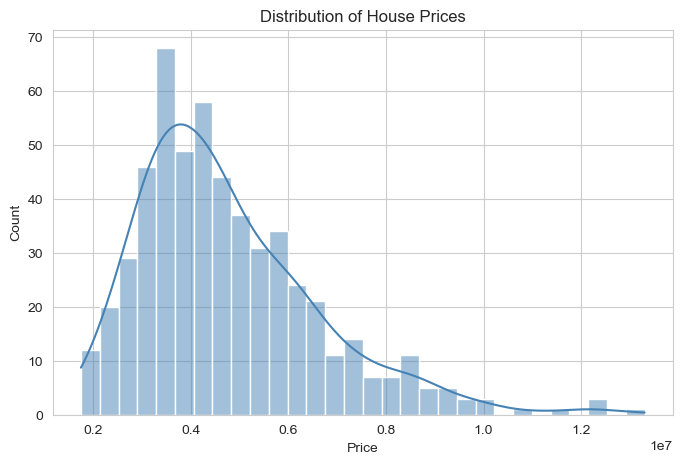

In [29]:
# Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

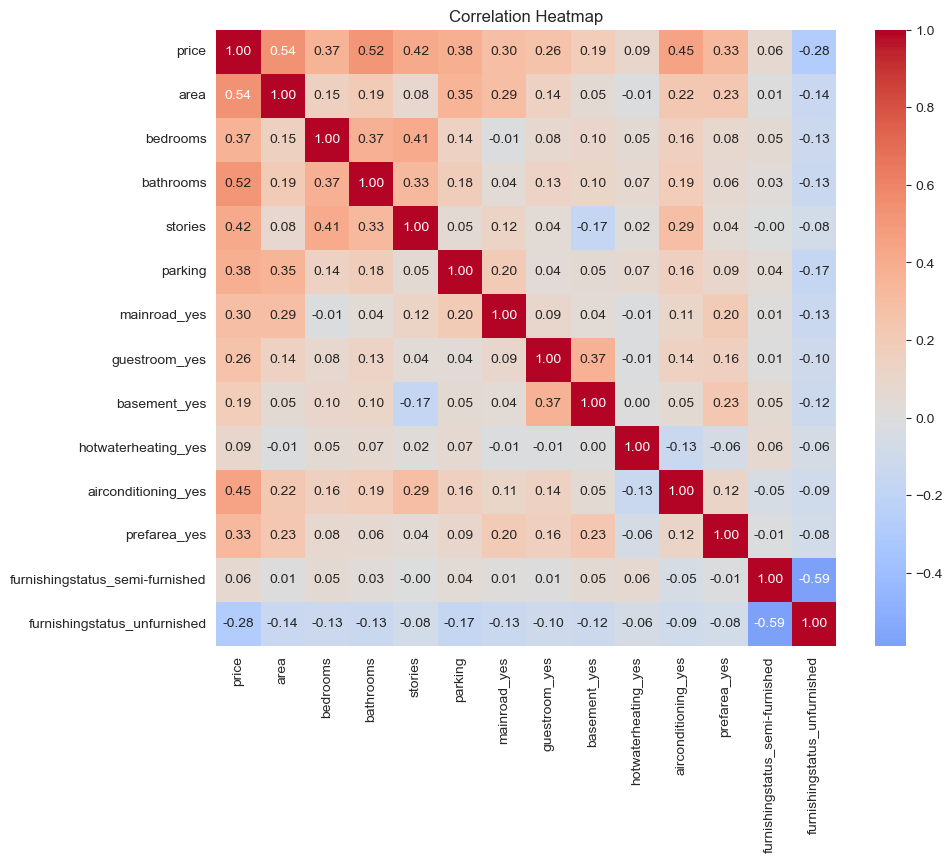

area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
furnishingstatus_unfurnished      -0.280587
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
Name: price, dtype: float64

In [31]:
#Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(10,8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Ranked list of correlations with price
corr["price"].drop("price").sort_values(key=abs, ascending=False)

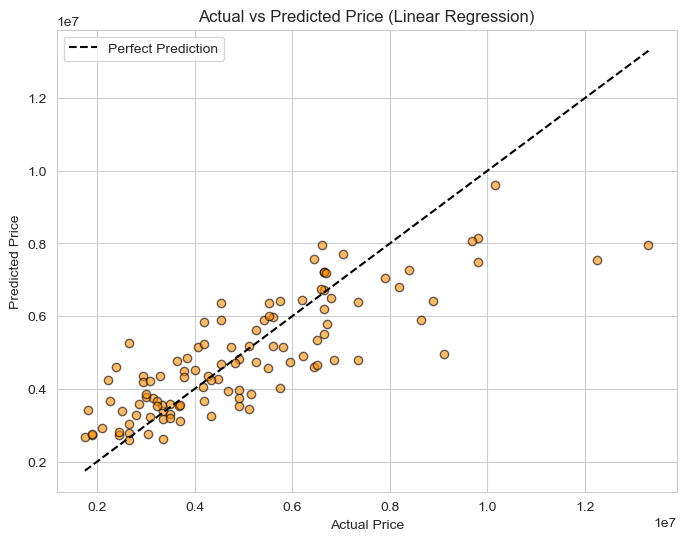

In [33]:
#Chart 3: Actual vs. Predicted scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred, alpha=0.6, color="darkorange", edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", label="Perfect Prediction")
plt.title("Actual vs Predicted Price (Linear Regression)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

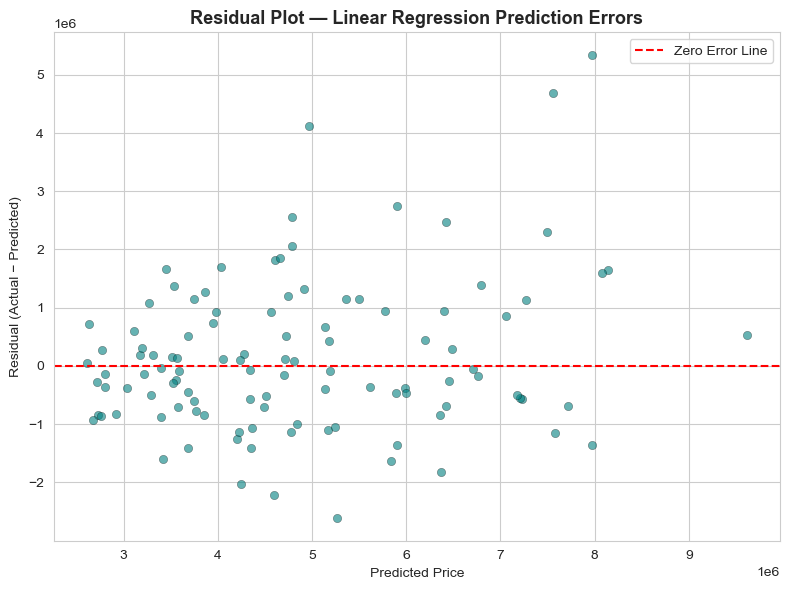

In [34]:
#Residual Plot
residuals = y_test - lr_pred

plt.figure(figsize=(8,6))
plt.scatter(lr_pred, residuals, alpha=0.6, color="teal", edgecolor="k", linewidth=0.3)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5, label="Zero Error Line")
plt.title("Residual Plot — Linear Regression Prediction Errors", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual − Predicted)")
plt.legend()
plt.tight_layout()
plt.show()

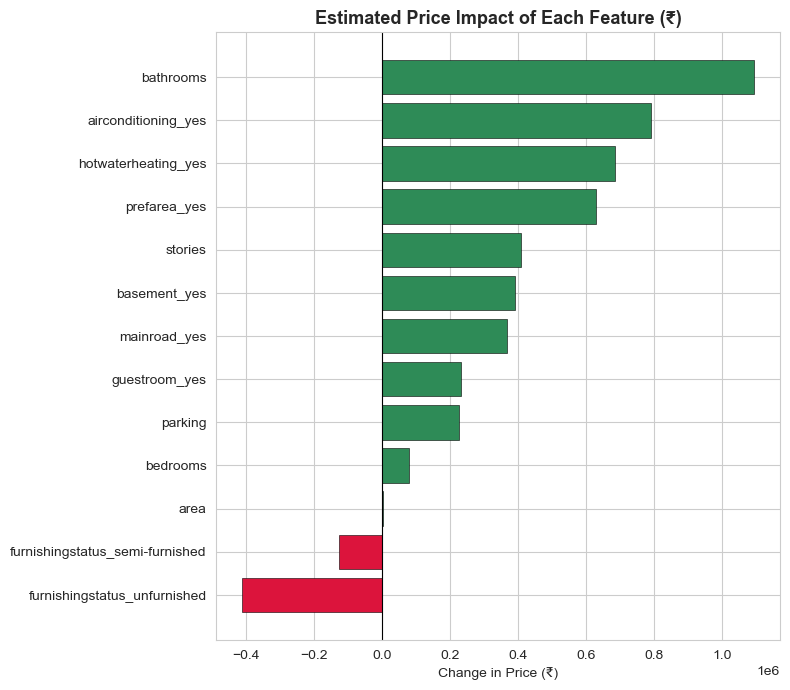

In [35]:
#Price Premium per Feature
coefs = pd.Series(lr_model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8,7))
colors = ["crimson" if v < 0 else "seagreen" for v in coefs.values]
plt.barh(coefs.index, coefs.values, color=colors, edgecolor="black", linewidth=0.4)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Estimated Price Impact of Each Feature (₹)", fontsize=13, fontweight="bold")
plt.xlabel("Change in Price (₹)")
plt.tight_layout()
plt.show()

In [ ]:
#Task 5-Insights & Summary
The biggest takeaway for me was that area turned out to be the most important factor in determining house prices.
It had the strongest correlation with price, and the Random Forest model also confirmed this by giving it the highest importance score by a clear margin.
Bathrooms and having air conditioning (AC) came next, which makes sense because they usually indicate a more modern and well-equipped house.

My Linear Regression model was able to explain about 65% of the variation in house prices (R² ≈ 0.65), and on average its predictions were off by around ₹9-10 lakh.
So, while it gives a reasonable estimate, it is not accurate enough for exact property valuation.

One thing that surprised me was that the number of bedrooms had much less impact on price than area or bathrooms.
I expected houses with more bedrooms to always be more expensive, but the data did not really support that assumption. 
I was also surprised that the more advanced Random Forest model did not outperform the simpler Linear Regression model. 
This showed me that a more complex model is not always more accurate, especially when working with a relatively small dataset.

If I had to give one recommendation to a real estate business, it would be to focus on highlighting area,bathroom count, and amenities such as **AC** in property listings, since these factors appear to have the greatest influence on house prices compared to bedroom count.
